# **WSINDy for ODEs: Examples**

- Based on the [SIAM MMS paper by **D. A. Messenger**, **D. M. Bortz** (2021)](https://epubs.siam.org/doi/10.1137/20M1343166).
<!-- - See the authors' original [MatLab code repository](https://github.com/MathBioCU/WSINDy_PDE). -->

April Tran, Dan Messenger, 2026

---

This notebook illustrates the WSINDy algorithm being applied to various ODE systems
<!-- - the $(1+1)$-dimensional Kuramoto Sivashinsky equation
- the $(2+1)$-dimensional Swift Hohenberg equation
- the $(3+1)$-dimensional MHD equations -->

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.pylab as plt
import math
from scipy.integrate import solve_ivp
import time

import os
import sys
import json
from pathlib import Path
try:
    kernel_info_path = Path(sys.argv[-1])
    notebook_path = json.loads(kernel_info_path.read_bytes())['jupyter_session']
    notebook_dir = os.path.dirname(notebook_path)
except (IndexError, KeyError, json.JSONDecodeError, FileNotFoundError):
    # Fallback to current working directory if parsing fails
    notebook_dir = os.getcwd() 
parent_dir = os.path.dirname(notebook_dir)
sys.path.append(parent_dir+'/libs/pywsindy_base')

from wsindy_ode import *
from ode_systems import *

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


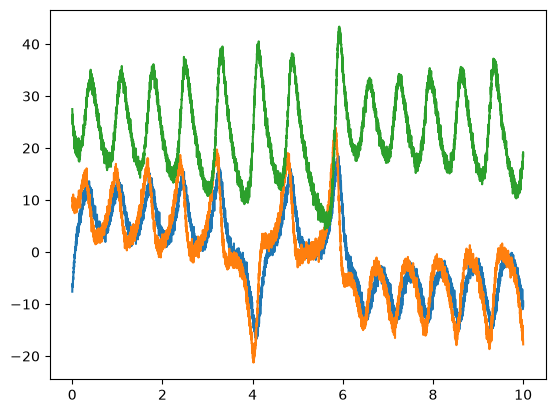

In [43]:
ode_num = -1 # select ODE system from the list ode_names                    # sol_ivp tolerance (abs and rel) for generating data                     
noise_ratio = 0.05  #set signal-to-noise ratio(L2 sense)
np.random.seed(42)                 #reproducibility 
use_preset_params = True           #Use parameters specified in gen_data

#ode params
ode_names = ['Linear','Logistic_Growth','Van_der_Pol','Duffing','Lotka_Volterra','Lorenz']
ode_name = ode_names[ode_num]
    
weights, t, xobs, rhs, x0 = simODE(ode_name, noise_ratio)
plt.plot(t,xobs)

In [45]:
WSINDy_model = wsindy(polys=np.arange(0, 4))

#Uniform
WSINDy_model.getWSindyUniform(xobs, t, L = 25, overlap=0.8)

WSINDy_sim = WSINDy_model.simulate(t_span = np.array([t[0], t[-1]]), t_eval = t, x0 = x0)

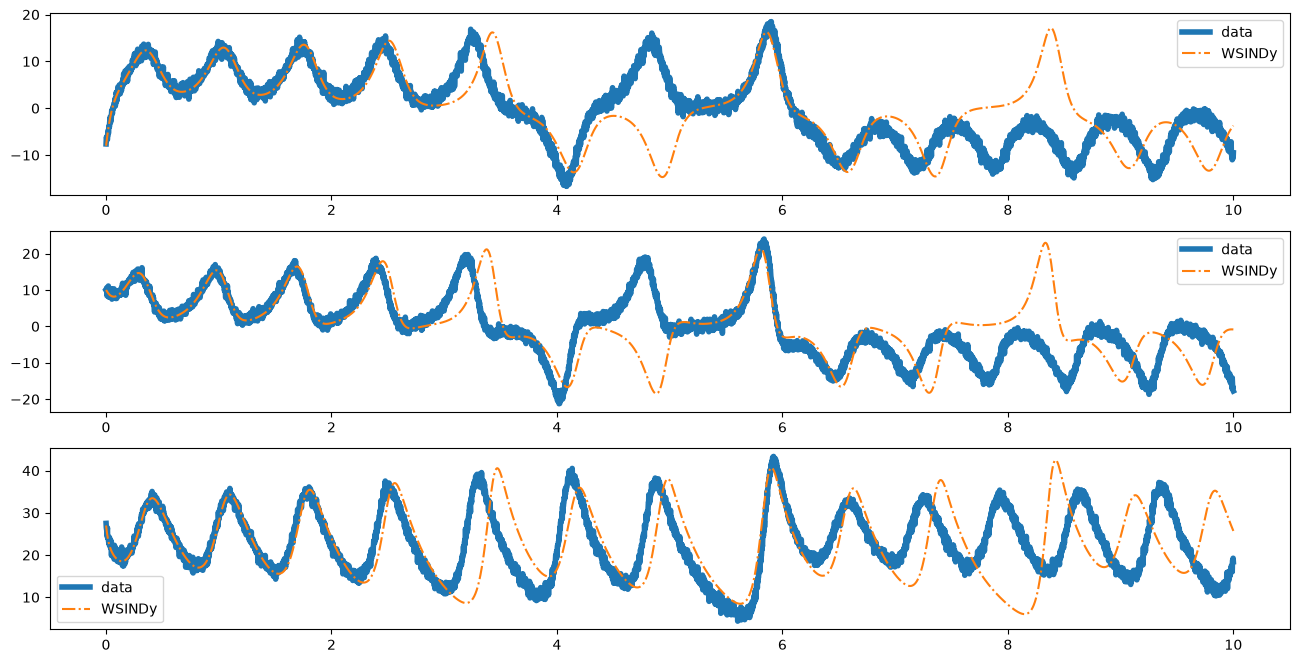

In [46]:
fig = plt.figure(figsize=(16, 8))
c = 1
n = xobs.shape[1]
for d in range(n):
    plt.subplot(n, 1, c)
    plt.plot(t, xobs[:, d], label = "data", linewidth = 4)
    plt.plot(t, WSINDy_sim[:, d], linestyle='dashdot', label = 'WSINDy') #marker = 'v', markevery = 200)
    c = c + 1
    plt.legend()